# K-Means + Silhouette Score + PCA (Wine dataset)

Este notebook es **para principiantes** y muestra un flujo típico de clustering:

1. Cargar un dataset sencillo (Wine, conocido como “UCI Wine”, disponible en `sklearn`).
2. Preprocesar (escalado).
3. Probar distintos valores de **k** en **K-Means**.
4. Elegir **k** usando **Silhouette Score**.
5. Reducir a 2D con **PCA** para **visualizar** los clusters.

> Nota: En clustering **no hay “verdad”** (labels) para evaluar como en clasificación; por eso usamos métricas internas como silhouette.


In [1]:
# Si estás en Colab, normalmente ya vienen instaladas estas librerías.
# Si no, instala con:
# !pip install -U scikit-learn matplotlib numpy pandas

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Para reproducibilidad
RANDOM_STATE = 42


## 1) Cargar datos (Wine)

Usamos el dataset `load_wine()` de scikit-learn, que corresponde al clásico Wine de UCI.
Tiene 13 features numéricas (características químicas) y 3 clases reales (pero **no las usamos** para entrenar el clustering).


In [2]:
wine = load_wine()
X = wine.data
feature_names = wine.feature_names

import pandas as pd
df = pd.DataFrame(X, columns=feature_names)
df.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [3]:
print("Shape X:", X.shape)
print("Número de features:", X.shape[1])


Shape X: (178, 13)
Número de features: 13


## 2) Escalado (muy importante en K-Means)

K-Means se basa en distancias (euclídeas). Si una feature tiene escala mayor, dominará el resultado.
Por eso usamos **StandardScaler** (media 0, desviación 1).


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Chequeo rápido: medias ~0 y std ~1 (aprox)
print("Mean (first 5 features):", X_scaled.mean(axis=0)[:5])
print("Std  (first 5 features):", X_scaled.std(axis=0)[:5])


Mean (first 5 features): [ 7.84141790e-15  2.44498554e-16 -4.05917497e-15 -7.11041712e-17
 -2.49488320e-17]
Std  (first 5 features): [1. 1. 1. 1. 1.]


## 3) Probar distintos k y calcular Silhouette Score

- **Silhouette Score** va de -1 a 1.
- Valores más altos suelen indicar clusters más separados y compactos.
- Recomendación práctica: probar k en un rango razonable (por ejemplo 2 a 10).

> Importante: silhouette no es perfecto; a veces conviene combinarlo con sentido de negocio/interpretación.


In [5]:
k_values = range(2, 11)
sil_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

sil_scores


[0.2650328591008738,
 0.2848589191898987,
 0.25422758316007776,
 0.1836210510769814,
 0.16899191019013057,
 0.17260155610949213,
 0.16250411307671145,
 0.17387393345450863,
 0.13956723664297552]

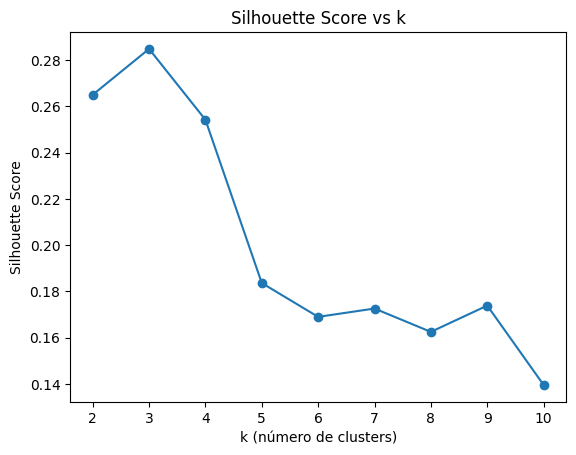

Mejor k según silhouette: 3 (score=0.2849)


In [6]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.plot(list(k_values), sil_scores, marker="o")
plt.xticks(list(k_values))
plt.xlabel("k (número de clusters)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.show()

best_k = int(list(k_values)[int(np.argmax(sil_scores))])
best_score = float(np.max(sil_scores))
print(f"Mejor k según silhouette: {best_k} (score={best_score:.4f})")


## 4) Entrenar K-Means con el k elegido

Entrenamos el modelo final con el **k** que maximizó silhouette.


In [7]:
kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init="auto")
clusters = kmeans_final.fit_predict(X_scaled)

# Agregamos el cluster al dataframe para inspección rápida
df_clusters = df.copy()
df_clusters["cluster"] = clusters
df_clusters.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,cluster
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,2
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,2
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,2
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,2
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,2


In [8]:
df_clusters["cluster"].value_counts().sort_index()


cluster
0    65
1    51
2    62
Name: count, dtype: int64

## 5) PCA para visualizar en 2D

PCA reduce dimensionalidad. Aquí lo usamos SOLO para **graficar** en 2D.

- Ajustamos PCA con 2 componentes sobre `X_scaled`.
- Proyectamos a 2D.
- Graficamos puntos coloreados por cluster.


In [9]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print("Varianza explicada por componente:", pca.explained_variance_ratio_)
print("Varianza explicada total (2 componentes):", pca.explained_variance_ratio_.sum())


Varianza explicada por componente: [0.36198848 0.1920749 ]
Varianza explicada total (2 componentes): 0.5540633835693527


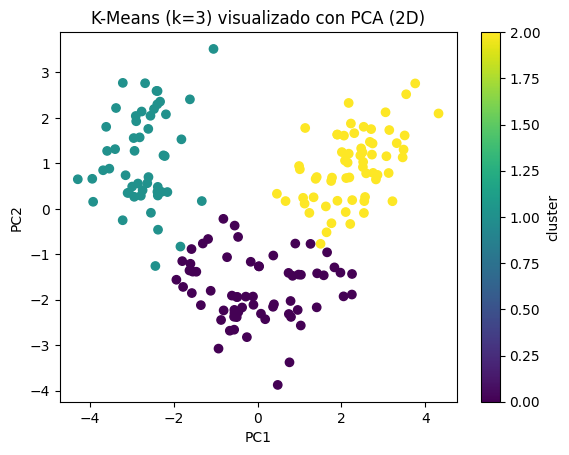

In [10]:
plt.figure()
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"K-Means (k={best_k}) visualizado con PCA (2D)")
plt.colorbar(scatter, label="cluster")
plt.show()


## Extra: comparar con las clases reales (solo referencia)

El dataset Wine tiene una etiqueta real (`target`) de 3 clases (tipos de vino).
**Ojo:** en clustering no deberías depender de esto, pero sirve como curiosidad para ver si el agrupamiento “se parece”.

(No es parte del pipeline de clustering, es sólo inspección.)


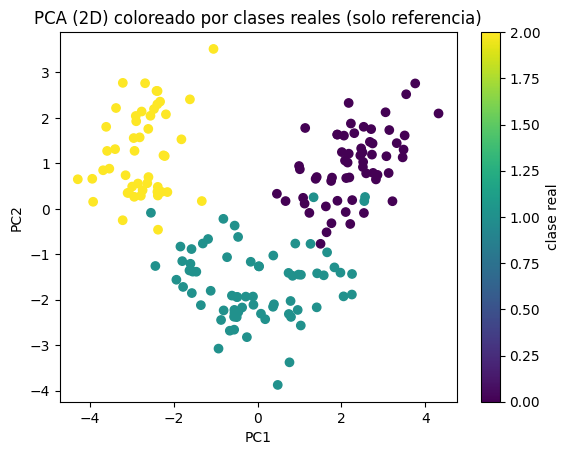

Bad pipe message: %s [b'\x96\x15\xc6\x01\xff\xc1\xed\xdb>\\\x19K]^\xb1\x95\x92.\x00\x00\x84\x003\x009\x005\x00/\xc0,\xc00\x00\xa3\x00\x9f\xcc\xa9\xcc\xa8\xcc\xaa\xc0\xaf\xc0\xad\xc0\xa3\xc0\x9f\xc0+\xc0/\x00\xa2\x00\x9e\xc0\xae\xc0\xac\xc0', b"\x9e\xc0$\xc0(\x00k\x00j\xc0s\xc0w\x00\xc4\x00\xc3\xc0#\xc0'\x00g\x00@\xc0r\xc0v\x00\xbe\x00\xbd\xc0\n\xc0\x14\x008\x00\x88\x00\x87\xc0\t\xc0\x13\x002\x00\x9a\x00\x99\x00E\x00D\x00\x9d\xc0\xa1\xc0\x9d\x00\x9c\xc0\xa0\xc0\x9c\x00=\x00\xc0\x00<\x00\xba\x00\x84\x00\x96\x00A\x00\x07\x00\xff\x01\x00\x00F\x00\x0b\x00\x04\x03\x00\x01\x02\x00\n\x00\n\x00\x08\x00\x1d\x00\x17\x00\x19\x00\x18\x00#\x00\x00\x00\x16\x00\x00\x00\x17\x00\x00\x00\r\x00 \x00\x1e\x06\x01\x06\x02\x06\x03\x05\x01\x05\x02\x05\x03\x04\x01\x04\x02\x04\x03\x03\x01\x03\x02\x03\x03\x02\x01\x02\x02\x02\x03"]
Bad pipe message: %s [b'8%\xc5O\xde\xa1\t\xd5x\xe6}U\xc1\xfd\xc4\x94!\x02\x00\x00\x1a\x13\x05\x13\x04\x13\x01\x13\x02\x13\x03\xc0\xb4\xc0\xb5\x00\xc7\x00\xc6\xc0\xb2\xc0\xb0\xc0\xb3\xc0

In [ ]:
y_true = wine.target

pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca2.fit_transform(X_scaled)

plt.figure()
scatter = plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c=y_true)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (2D) coloreado por clases reales (solo referencia)")
plt.colorbar(scatter, label="clase real")
plt.show()


## Conclusiones

- **K-Means** necesita features numéricas y funciona mejor cuando los clusters son aproximadamente “esféricos” en el espacio.
- **Escalar** suele ser imprescindible.
- **Silhouette Score** ayuda a elegir k, pero no reemplaza criterio e interpretación.
- **PCA** es útil para visualizar (aunque comprime información).
